# 🏠 Smart Room AI — Modélisation de la consommation énergétique

Notebook de modélisation suivant la méthodologie **CRISP-DM** :

1. **Business Understanding** — objectifs métier, contraintes et critères de succès
2. **Data Understanding** — exploration du dataset UCI *Appliances energy prediction*
3. **Data Preparation** — nettoyage, variables temporelles, sélection des capteurs Smart Room
4. **Modeling** — baselines, Random Forest complet, Random Forest Smart Room
5. **Evaluation** — métriques, importance des variables, analyse des erreurs, validation croisée, lecture métier

La phase 6 (*Deployment*) est assurée par le backend Flask (`backend/`), qui charge le modèle exporté à la fin de ce notebook.

## 1. Business Understanding

### Contexte
La **Smart Room** est une pièce équipée de capteurs (température, humidité, luminosité, pression, présence, tension, courant). L'application doit :

- **prédire la consommation électrique** de la pièce à partir des capteurs ;
- convertir cette consommation en **coût** (TND) et la comparer à un **objectif financier** ;
- produire des **conseils** (pièce vide, surtension, surcharge, consommation élevée).

Le coût, le budget et les conseils sont des règles métier simples (implémentées dans `backend/advice_engine.py`) ; la seule partie « apprentissage » est la prédiction de la consommation.

### Objectif de data mining
Problème de **régression** : prédire `Appliances`, l'énergie consommée par les appareils sur un intervalle de 10 minutes (Wh), à partir de mesures environnementales et de l'heure.

### Contraintes
- Le modèle déployé ne doit utiliser que des variables **disponibles dans la Smart Room** : une température, une humidité, un niveau de lumière, la pression, la température extérieure, le point de rosée et l'heure — soit **7 variables**.
- Le modèle doit être **léger** et se charger rapidement dans une application Flask (fichier scikit-learn sérialisé avec joblib) : **≤ 20 Mo** sur disque.

### Critères de succès
- Faire nettement mieux qu'une prédiction naïve (moyenne) : **R² > 0,5** sur le jeu de test.
- Une erreur absolue moyenne (**MAE**) faible au regard de la consommation médiane (~60 Wh / 10 min).
- Une perte de performance **limitée** entre le modèle « complet » (tous les capteurs de la maison) et le modèle « Smart Room » (7 variables).
- Un modèle exporté qui respecte le **budget de taille** de 20 Mo.

In [1]:
import io
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
TARGET = "Appliances"

# Racine du projet = premier dossier parent contenant `data/`
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Dossier data/ introuvable : ouvrez le notebook depuis le projet.")
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "energydata_complete.csv"
MODELS_DIR = PROJECT_ROOT / "models"

print("Projet :", PROJECT_ROOT)

Projet : C:\Users\oussa\Desktop\Repos\SmartRoomMonitoring


## 2. Data Understanding

Le dataset [Appliances energy prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction) (UCI, Candanedo et al. 2017) contient 4,5 mois de relevés toutes les 10 minutes dans une maison basse consommation en Belgique.

| Colonnes | Description |
| --- | --- |
| `date` | horodatage (pas de 10 min) |
| `Appliances` | **cible** — énergie consommée par les appareils (Wh) |
| `lights` | énergie des luminaires (Wh) — utilisée ici comme *niveau de lumière* de la pièce |
| `T1`…`T9`, `RH_1`…`RH_9` | température (°C) et humidité (%) de 9 pièces de la maison |
| `T_out`, `RH_out`, `Press_mm_hg`, `Windspeed`, `Visibility`, `Tdewpoint` | météo extérieure (station de Chièvres) |
| `rv1`, `rv2` | variables aléatoires ajoutées par les auteurs (contrôle) |

### 2.1 Chargement

In [2]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print(f"{df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

19735 lignes × 29 colonnes


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### 2.2 Qualité des données

In [3]:
print("Valeurs manquantes :", int(df.isnull().sum().sum()))
print("Lignes dupliquées  :", int(df.duplicated().sum()))
print("\nTypes de colonnes :")
print(df.dtypes.value_counts().to_string())

df.describe().T.round(2)

Valeurs manquantes : 0
Lignes dupliquées  : 0

Types de colonnes :
float64           26
int64              2
datetime64[us]     1


,count,mean,min,25%,50%,75%,max,std
date,19735,2016-03-20 05:29:59.999999,2016-01-11 17:00:00,2016-02-14 23:15:00,2016-03-20 05:30:00,2016-04-23 11:45:00,2016-05-27 18:00:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


### 2.3 Couverture temporelle

In [4]:
steps = df["date"].diff().dropna()
usual_step = steps.mode()[0]

print("Période      :", df["date"].min(), "→", df["date"].max())
print("Durée        :", df["date"].max() - df["date"].min())
print("Pas de temps :", usual_step, "| relevés irréguliers :", int((steps != usual_step).sum()))

Période      : 2016-01-11 17:00:00 → 2016-05-27 18:00:00
Durée        : 137 days 01:00:00
Pas de temps : 0 days 00:10:00 | relevés irréguliers : 0


### 2.4 Variable cible `Appliances`

count    19735.0
mean        97.7
std        102.5
min         10.0
25%         50.0
50%         60.0
75%        100.0
max       1080.0

Asymétrie (skewness) : 3.39


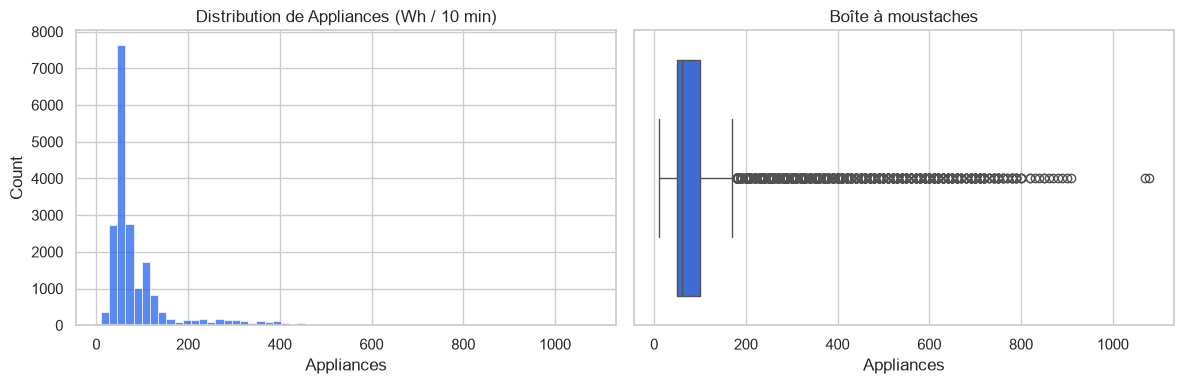

In [5]:
print(df[TARGET].describe().round(1).to_string())
print(f"\nAsymétrie (skewness) : {df[TARGET].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=60, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution de Appliances (Wh / 10 min)")
sns.boxplot(x=df[TARGET], ax=axes[1], color="#2563eb")
axes[1].set_title("Boîte à moustaches")
plt.tight_layout()
plt.show()

### 2.5 Profils temporels

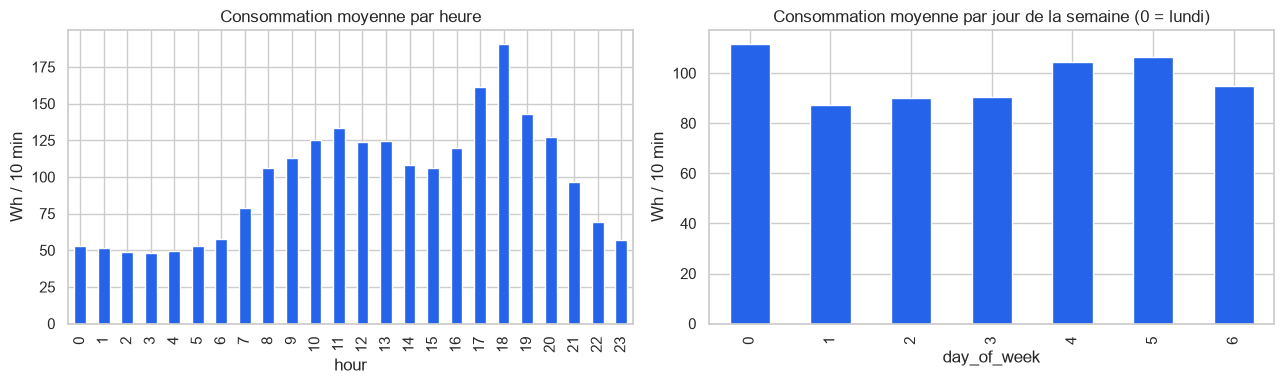

In [6]:
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek  # 0 = lundi

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.groupby("hour")[TARGET].mean().plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("Consommation moyenne par heure")
axes[0].set_ylabel("Wh / 10 min")
df.groupby("day_of_week")[TARGET].mean().plot(kind="bar", ax=axes[1], color="#2563eb")
axes[1].set_title("Consommation moyenne par jour de la semaine (0 = lundi)")
axes[1].set_ylabel("Wh / 10 min")
plt.tight_layout()
plt.show()

### 2.6 Corrélations avec la cible

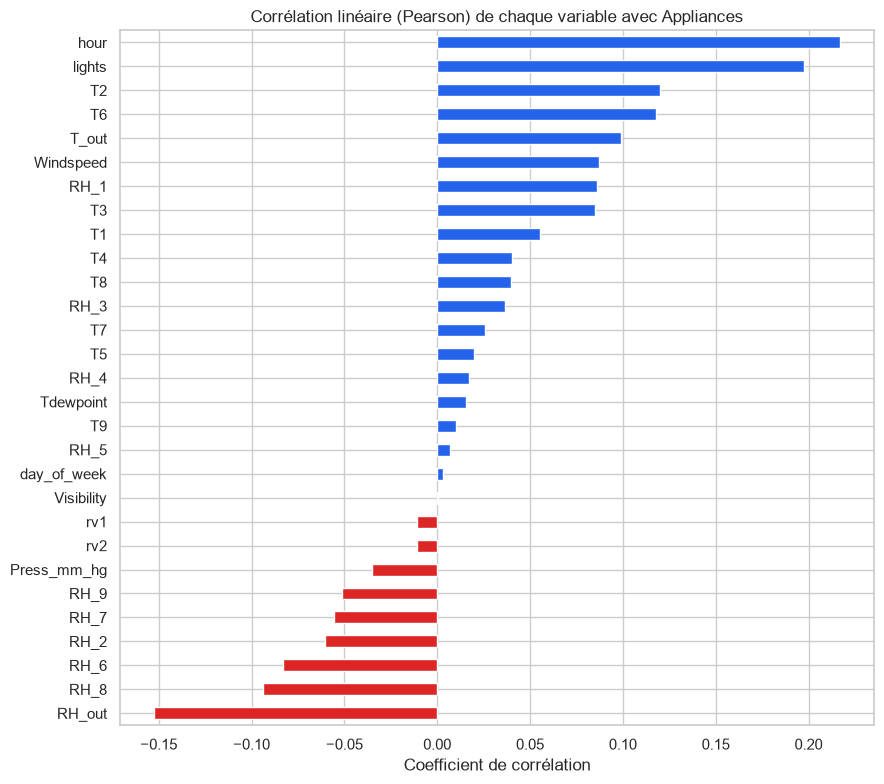

Variables les plus corrélées (valeur absolue) :
hour         0.217
lights       0.197
RH_out       0.152
T2           0.120
T6           0.118
T_out        0.099
RH_8         0.094
Windspeed    0.087
RH_1         0.086
T3           0.085


In [7]:
correlations = df.drop(columns=["date"]).corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(9, 8))
correlations.plot(kind="barh", color=np.where(correlations > 0, "#2563eb", "#dc2626"))
plt.title("Corrélation linéaire (Pearson) de chaque variable avec Appliances")
plt.xlabel("Coefficient de corrélation")
plt.tight_layout()
plt.show()

print("Variables les plus corrélées (valeur absolue) :")
print(correlations.abs().sort_values(ascending=False).head(10).round(3).to_string())

### 2.7 Observations

- Le dataset est **propre** : aucune valeur manquante, pas de doublon, pas de 10 minutes régulier.
- La cible est **très asymétrique** : la plupart des relevés sont bas (médiane ≈ 60 Wh) avec une longue queue de pics de consommation (jusqu'à > 1 000 Wh). Les pics seront les plus difficiles à prédire.
- Le **profil horaire** est net : consommation faible la nuit, pics en fin de journée. L'heure est donc une variable clé.
- Les **corrélations linéaires** avec la cible sont toutes faibles (|r| < 0,3) : la relation est non linéaire et multi-variée, ce qui justifie un modèle d'ensemble (Random Forest) plutôt qu'une régression linéaire.
- `rv1` et `rv2` sont du bruit aléatoire : elles seront supprimées.

## 3. Data Preparation

### 3.1 Nettoyage et variables temporelles

In [8]:
data = df.drop_duplicates().copy()

# rv1 / rv2 : bruit aléatoire sans signification physique
data = data.drop(columns=["rv1", "rv2"])

# Variables temporelles supplémentaires (hour et day_of_week ont été créées en 2.5)
data["month"] = data["date"].dt.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

# L'horodatage brut n'est pas exploitable directement par le modèle
data = data.drop(columns=["date"])

print(data.shape)
data.head()

(19735, 30)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day_of_week,month,is_weekend
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,17,0,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,17,0,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,17,0,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,17,0,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,17,0,1,0


### 3.2 Deux jeux de variables

- **Jeu complet** : toutes les colonnes restantes. Il sert de référence (« que peut-on obtenir au mieux ? ») et à mesurer l'importance des variables.
- **Jeu Smart Room** : les 7 variables disponibles dans la pièce, renommées avec des noms métier. La pièce ne dispose que d'un capteur de température/humidité : on retient `T3`/`RH_3`, qui sont (après l'heure) les capteurs intérieurs les plus importants du modèle complet — voir §5.2.

In [9]:
SMART_ROOM_COLUMNS = {
    "hour": "hour",
    "T3": "temperature",
    "RH_3": "humidity",
    "lights": "light_level",
    "Press_mm_hg": "pressure",
    "T_out": "outdoor_temperature",
    "Tdewpoint": "dewpoint",
}

full_features = [column for column in data.columns if column != TARGET]
smart_features = list(SMART_ROOM_COLUMNS.values())

X_full = data[full_features]
X_smart = data[list(SMART_ROOM_COLUMNS)].rename(columns=SMART_ROOM_COLUMNS)
y = data[TARGET]

print(f"Jeu complet    : {len(full_features)} variables")
print(f"Jeu Smart Room : {len(smart_features)} variables → {smart_features}")

Jeu complet    : 29 variables
Jeu Smart Room : 7 variables → ['hour', 'temperature', 'humidity', 'light_level', 'pressure', 'outdoor_temperature', 'dewpoint']


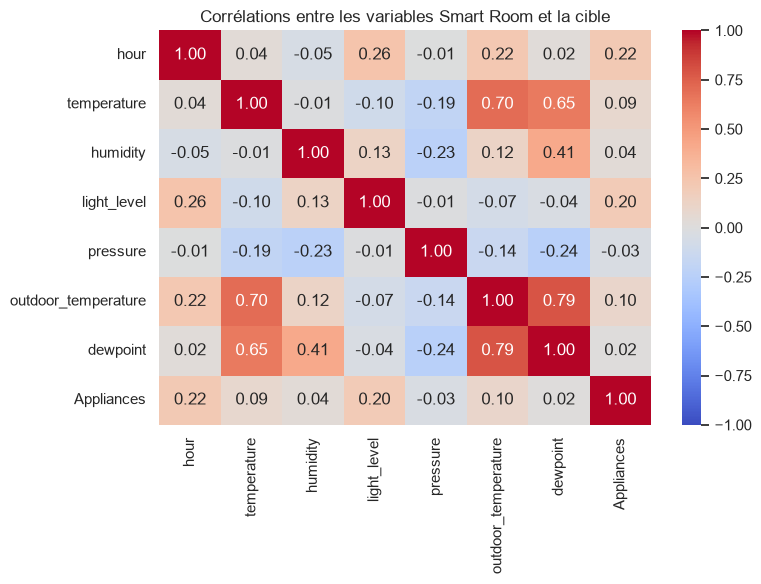

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.concat([X_smart, y], axis=1).corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
)
plt.title("Corrélations entre les variables Smart Room et la cible")
plt.tight_layout()
plt.show()

### 3.3 Partition entraînement / test

Partition aléatoire 80 / 20 (`random_state` fixé pour la reproductibilité). Les **mêmes lignes** sont utilisées pour le jeu complet et le jeu Smart Room afin que la comparaison des modèles soit équitable.

In [11]:
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE
)
X_smart_train = X_smart.loc[X_full_train.index]
X_smart_test = X_smart.loc[X_full_test.index]

print(f"Entraînement : {len(X_full_train)} lignes | Test : {len(X_full_test)} lignes")

Entraînement : 15788 lignes | Test : 3947 lignes


## 4. Modeling

Métriques utilisées (sur le jeu de test) :

- **MAE** (erreur absolue moyenne, en Wh) — lisible directement en énergie et en coût ;
- **RMSE** (racine de l'erreur quadratique moyenne) — pénalise davantage les grosses erreurs sur les pics ;
- **R²** — part de variance expliquée (1 = parfait, 0 = pas mieux que la moyenne).

In [12]:
def evaluate(name, model, X_test, y_test):
    """MAE, RMSE et R² d'un modèle entraîné, mesurés sur le jeu de test."""
    prediction = model.predict(X_test)
    return {
        "Modèle": name,
        "MAE (Wh)": mean_absolute_error(y_test, prediction),
        "RMSE (Wh)": mean_squared_error(y_test, prediction) ** 0.5,
        "R²": r2_score(y_test, prediction),
    }


results = []

### 4.1 Baselines

Deux références simples sur les variables Smart Room : la **moyenne** du jeu d'entraînement (aucune information) et une **régression linéaire**.

In [13]:
baseline = DummyRegressor(strategy="mean").fit(X_smart_train, y_train)
results.append(evaluate("Baseline — moyenne", baseline, X_smart_test, y_test))

linear = LinearRegression().fit(X_smart_train, y_train)
results.append(evaluate("Régression linéaire — Smart Room", linear, X_smart_test, y_test))

pd.DataFrame(results).round(3)

,Modèle,MAE (Wh),RMSE (Wh),R²
0,Baseline — moyenne,59.867,100.044,-0.000
1,Régression linéaire — Smart Room,53.953,94.541,0.107


### 4.2 Random Forest — jeu complet

Référence haute : un Random Forest avec **toutes** les variables de la maison.

In [14]:
rf_full = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_full.fit(X_full_train, y_train)

results.append(
    evaluate(f"Random Forest — complet ({len(full_features)} variables)", rf_full, X_full_test, y_test)
)
pd.DataFrame(results).round(3)

,Modèle,MAE (Wh),RMSE (Wh),R²
0,Baseline — moyenne,59.867,100.044,-0.000
1,Régression linéaire — Smart Room,53.953,94.541,0.107
2,Random Forest — complet (29 variables),30.780,65.843,0.567


### 4.3 Random Forest — Smart Room (modèle à déployer)

Le réglage des hyperparamètres utilise le **score out-of-bag (OOB)** : chaque arbre est évalué sur les lignes qu'il n'a pas vues lors du bootstrap. On obtient ainsi une estimation de généralisation **sans toucher au jeu de test**, qui reste réservé à l'évaluation finale.

Chaque configuration est aussi mesurée par la **taille du modèle exporté** (joblib compressé), car un Random Forest d'arbres entièrement développés devient vite très lourd. La sélection retient le meilleur R² OOB **parmi les configurations qui respectent le budget de 20 Mo** fixé en §1.

In [15]:
SIZE_BUDGET_MB = 20  # contrainte de déploiement fixée en §1

configurations = [
    {"n_estimators": 50, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 20, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 3},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 5},
]


def exported_size_mb(model):
    """Taille (Mo) du modèle tel qu'il sera exporté pour le backend (joblib, compress=3)."""
    buffer = io.BytesIO()
    joblib.dump(model, buffer, compress=3)
    return buffer.tell() / 1e6


tuning = []
for params in configurations:
    start = time.perf_counter()
    model = RandomForestRegressor(
        oob_score=True, random_state=RANDOM_STATE, n_jobs=-1, **params
    ).fit(X_smart_train, y_train)
    tuning.append(
        {
            **params,
            "R² OOB": model.oob_score_,
            "taille (Mo)": exported_size_mb(model),
            "nœuds (millions)": sum(tree.tree_.node_count for tree in model.estimators_) / 1e6,
            "entraînement (s)": time.perf_counter() - start,
        }
    )

tuning = pd.DataFrame(tuning)
tuning["respecte le budget"] = tuning["taille (Mo)"] <= SIZE_BUDGET_MB
tuning.round(3)

,n_estimators,max_depth,min_samples_leaf,R² OOB,taille (Mo),nœuds (millions),entraînement (s),respecte le budget
0,50,NaN,1,0.508,9.064,0.668,0.981,True
1,100,NaN,1,0.520,18.088,1.336,2.079,True
2,200,NaN,1,0.527,36.126,2.670,3.567,False
3,400,NaN,1,0.532,72.177,5.337,7.502,False
4,100,20.0,1,0.516,14.849,1.039,1.656,True
5,100,NaN,3,0.481,9.815,0.549,1.245,True
6,100,NaN,5,0.447,6.485,0.321,1.106,True


Deux enseignements :

- **`min_samples_leaf`** dégrade fortement le R² OOB dès qu'on l'augmente : le modèle tire parti de relevés quasi identiques (deux mesures à 10 minutes d'intervalle se ressemblent beaucoup). C'est efficace sur cette partition aléatoire, mais c'est aussi une forme d'optimisme — voir les limites en §5.6.
- Le **nombre d'arbres** n'apporte plus grand-chose au-delà de 100, alors que la taille du modèle croît linéairement. Le budget de 20 Mo tranche.

In [16]:
eligible = tuning[tuning["respecte le budget"]]
best = eligible.sort_values("R² OOB", ascending=False).iloc[0]
best_params = {
    "n_estimators": int(best["n_estimators"]),
    "max_depth": None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
    "min_samples_leaf": int(best["min_samples_leaf"]),
}

print(f"Meilleure configuration sous {SIZE_BUDGET_MB} Mo :", best_params)
print(f"R² OOB = {best['R² OOB']:.4f} | meilleur R² OOB toutes tailles confondues = {tuning['R² OOB'].max():.4f}")

rf_smart = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
rf_smart.fit(X_smart_train, y_train)

results.append(evaluate("Random Forest — Smart Room (7 variables)", rf_smart, X_smart_test, y_test))
pd.DataFrame(results).round(3)

Meilleure configuration sous 20 Mo : {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1}
R² OOB = 0.5200 | meilleur R² OOB toutes tailles confondues = 0.5317


,Modèle,MAE (Wh),RMSE (Wh),R²
0,Baseline — moyenne,59.867,100.044,-0.000
1,Régression linéaire — Smart Room,53.953,94.541,0.107
2,Random Forest — complet (29 variables),30.780,65.843,0.567
3,Random Forest — Smart Room (7 variables),31.741,67.166,0.549


## 5. Evaluation

### 5.1 Comparaison des modèles

In [17]:
summary = pd.DataFrame(results).set_index("Modèle")
summary.round(3)

,MAE (Wh),RMSE (Wh),R²
Modèle,,,
Baseline — moyenne,59.867,100.044,-0.000
Régression linéaire — Smart Room,53.953,94.541,0.107
Random Forest — complet (29 variables),30.780,65.843,0.567
Random Forest — Smart Room (7 variables),31.741,67.166,0.549


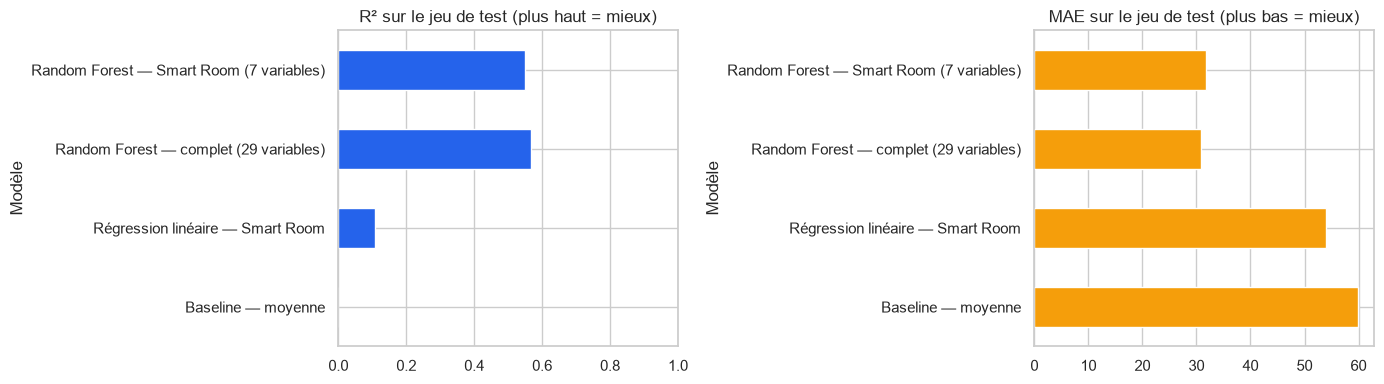

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
summary["R²"].plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("R² sur le jeu de test (plus haut = mieux)")
axes[0].set_xlim(0, 1)
summary["MAE (Wh)"].plot(kind="barh", ax=axes[1], color="#f59e0b")
axes[1].set_title("MAE sur le jeu de test (plus bas = mieux)")
plt.tight_layout()
plt.show()

### 5.2 Importance des variables

L'importance du modèle complet justifie le choix des capteurs Smart Room ; celle du modèle Smart Room montre sur quoi repose la prédiction déployée.

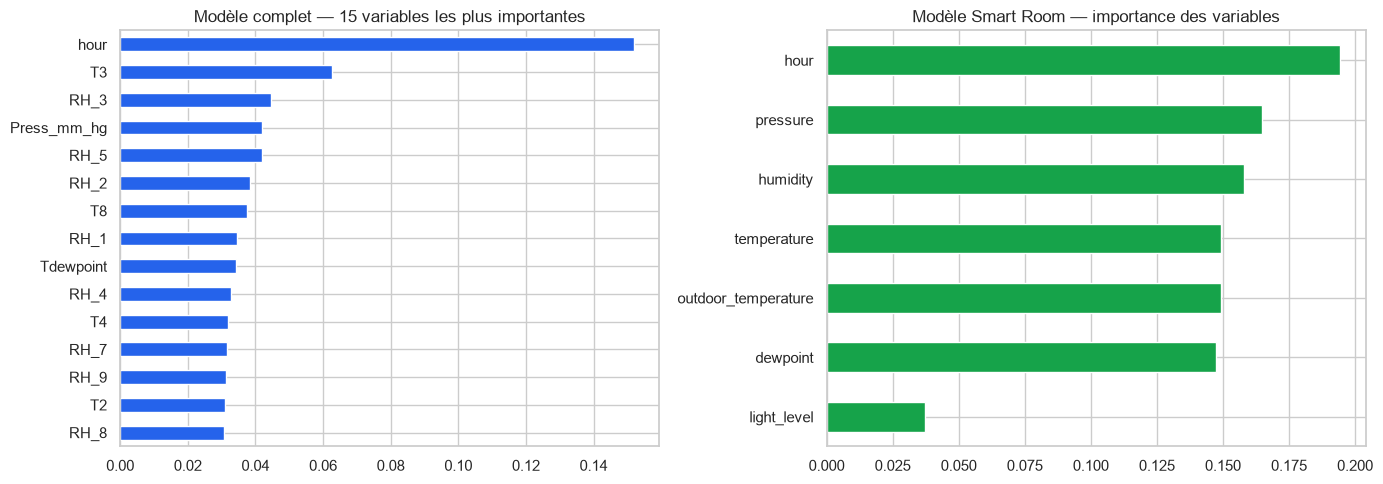

Rang des capteurs Smart Room dans le modèle complet :
hour            1
T3              2
RH_3            3
lights         19
Press_mm_hg     4
T_out          22
Tdewpoint       9


In [19]:
importance_full = pd.Series(rf_full.feature_importances_, index=full_features).sort_values(ascending=False)
importance_smart = pd.Series(rf_smart.feature_importances_, index=smart_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_full.head(15).sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Modèle complet — 15 variables les plus importantes")
importance_smart.sort_values().plot(kind="barh", ax=axes[1], color="#16a34a")
axes[1].set_title("Modèle Smart Room — importance des variables")
plt.tight_layout()
plt.show()

print("Rang des capteurs Smart Room dans le modèle complet :")
ranks = importance_full.rank(ascending=False).astype(int)
print(ranks[list(SMART_ROOM_COLUMNS)].to_string())

### 5.3 Analyse des erreurs du modèle Smart Room

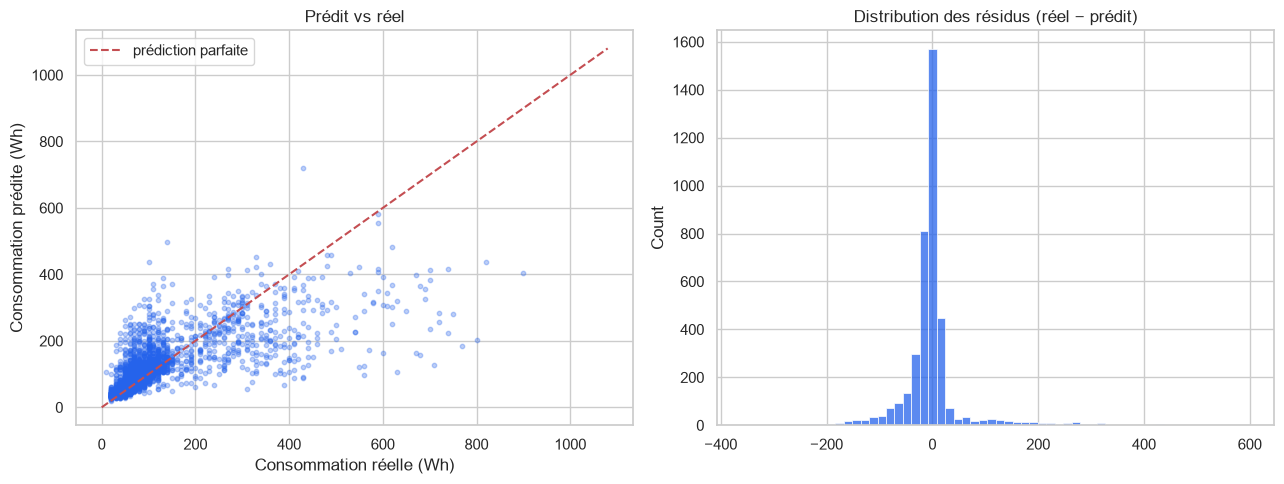

In [20]:
y_pred = pd.Series(rf_smart.predict(X_smart_test), index=y_test.index)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color="#2563eb")
limit = [0, float(y.max())]
axes[0].plot(limit, limit, "r--", label="prédiction parfaite")
axes[0].set_xlabel("Consommation réelle (Wh)")
axes[0].set_ylabel("Consommation prédite (Wh)")
axes[0].set_title("Prédit vs réel")
axes[0].legend()
sns.histplot(residuals, bins=60, ax=axes[1], color="#2563eb")
axes[1].set_title("Distribution des résidus (réel − prédit)")
plt.tight_layout()
plt.show()

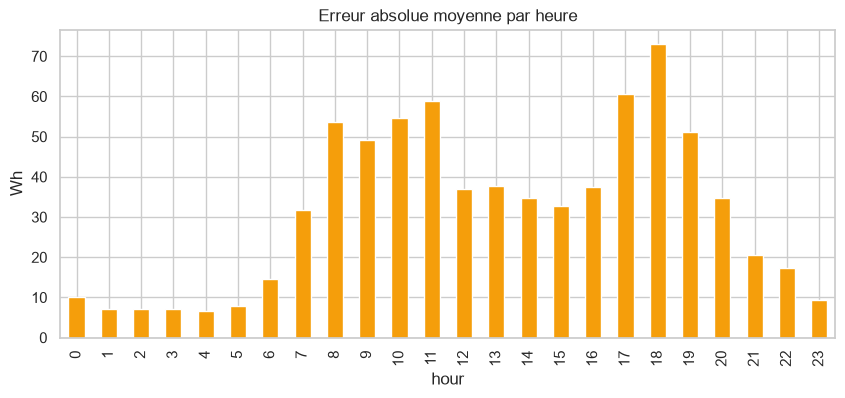

Erreur selon le niveau de consommation réel (Wh) :


,relevés,MAE (Wh)
niveau,,
"[0, 50)",619,15.9
"[50, 100)",2292,17.3
"[100, 200)",648,36.8
"[200, 400)",275,83.4
"[400, 1200)",113,256.1


In [21]:
error_by_hour = residuals.abs().groupby(X_smart_test["hour"]).mean()
error_by_level = (
    pd.DataFrame({"réel": y_test, "erreur absolue": residuals.abs()})
    .assign(niveau=lambda d: pd.cut(d["réel"], bins=[0, 50, 100, 200, 400, 1200], right=False))
    .groupby("niveau", observed=True)["erreur absolue"]
    .agg(["count", "mean"])
    .rename(columns={"count": "relevés", "mean": "MAE (Wh)"})
)

error_by_hour.plot(kind="bar", color="#f59e0b")
plt.title("Erreur absolue moyenne par heure")
plt.ylabel("Wh")
plt.show()

print("Erreur selon le niveau de consommation réel (Wh) :")
error_by_level.round(1)

### 5.4 Validation croisée

Robustesse du modèle Smart Room : R² sur 5 partitions différentes (K-Fold mélangé) de l'ensemble des données.

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params),
    X_smart, y, cv=cv, scoring="r2",
)
print("R² par pli :", cv_scores.round(3))
print(f"R² moyen   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

R² par pli : [0.555 0.516 0.533 0.544 0.527]
R² moyen   : 0.535 ± 0.014


### 5.5 Lecture métier et critères de succès

In [23]:
ELECTRICITY_PRICE = 0.3  # TND / kWh (valeur par défaut de l'application)

final = summary.loc["Random Forest — Smart Room (7 variables)"]
full = summary[summary.index.str.startswith("Random Forest — complet")].iloc[0]
baseline_mae = summary.loc["Baseline — moyenne", "MAE (Wh)"]

print(f"MAE du modèle déployé            : {final['MAE (Wh)']:.1f} Wh par relevé de 10 min")
print(f"  soit une erreur de coût de     : {final['MAE (Wh)'] / 1000 * ELECTRICITY_PRICE:.4f} TND par relevé")
print(f"Réduction de l'erreur vs baseline : {1 - final['MAE (Wh)'] / baseline_mae:.0%}")
print(f"R² Smart Room / R² complet        : {final['R²']:.3f} / {full['R²']:.3f} (écart {full['R²'] - final['R²']:.3f})")

model_size = exported_size_mb(rf_smart)
print(f"Taille du modèle exporté          : {model_size:.1f} Mo")
print()
print("Critère R² > 0,5 sur le jeu de test :", "✅ atteint" if final["R²"] > 0.5 else "❌ non atteint")
print(f"Critère taille ≤ {SIZE_BUDGET_MB} Mo             :", "✅ atteint" if model_size <= SIZE_BUDGET_MB else "❌ non atteint")

MAE du modèle déployé            : 31.7 Wh par relevé de 10 min
  soit une erreur de coût de     : 0.0095 TND par relevé
Réduction de l'erreur vs baseline : 47%
R² Smart Room / R² complet        : 0.549 / 0.567 (écart 0.018)


Taille du modèle exporté          : 18.0 Mo

Critère R² > 0,5 sur le jeu de test : ✅ atteint
Critère taille ≤ 20 Mo             : ✅ atteint


### 5.6 Conclusion

*(Chiffres arrondis ; les valeurs exactes sont dans les cellules ci-dessus.)*

- Le **Random Forest** fait nettement mieux que la moyenne (MAE ≈ 32 Wh contre 60 Wh, soit −48 %) et que la régression linéaire (R² ≈ 0,55 contre 0,11) : la relation capteurs → consommation est bien non linéaire.
- Le modèle **Smart Room (7 variables)** conserve l'essentiel de la performance du modèle complet à 29 variables (R² ≈ 0,55 contre 0,57), ce qui valide la contrainte métier : on peut déployer un modèle n'utilisant que les capteurs de la pièce. Le choix de `T3`/`RH_3` est confirmé : ce sont, avec l'heure et la pression, les 4 variables les plus importantes du modèle complet.
- L'**heure** est de loin la variable la plus importante, suivie de la température, de l'humidité et de la pression.
- Les erreurs sont très inégales : MAE ≈ 16 Wh sur les relevés courants (< 100 Wh, soit ~75 % des données) mais > 250 Wh sur les pics (> 400 Wh). Le modèle **sous-estime les pics**, ce qui est attendu avec une cible aussi asymétrique, et ce sont justement les moments où les conseils de l'application ont le plus de valeur.
- La validation croisée (5 plis) confirme la stabilité du R² (~0,53 ± 0,01).
- Le budget de taille conduit à **100 arbres** : environ 18 Mo compressés (contre ~380 Mo pour 400 arbres) pour une perte de R² OOB de l'ordre de 0,01. Tous les critères de succès sont atteints.

**Limites et pistes**

- La partition est aléatoire : des relevés voisins de 10 minutes se retrouvent des deux côtés, ce qui rend l'estimation optimiste. La chute du R² OOB dès que `min_samples_leaf` augmente (§4.3) montre que le modèle exploite ces quasi-doublons. Une partition **chronologique** donnerait une mesure plus proche d'un usage en production.
- `lights` est une consommation (Wh) utilisée comme proxy du niveau de lumière ; un vrai capteur de luminosité (lux) devra être re-calibré.
- Pistes : transformation logarithmique de la cible, gradient boosting, variables de retard (consommation des 10–30 minutes précédentes) si l'application enregistre l'historique.

### 5.7 Export du modèle pour le backend

Le backend Flask (`backend/model.py`) charge ces deux fichiers au démarrage : le modèle (joblib compressé) et la liste ordonnée de ses variables.

In [24]:
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / "smart_room_energy_model.pkl"
features_path = MODELS_DIR / "model_features.pkl"

joblib.dump(rf_smart, model_path, compress=3)
joblib.dump(smart_features, features_path)

start = time.perf_counter()
joblib.load(model_path)
load_time = time.perf_counter() - start

print(f"Modèle exporté : {model_path} ({model_path.stat().st_size / 1e6:.1f} Mo, chargé en {load_time:.2f} s)")
print(f"Variables      : {features_path} → {smart_features}")

Modèle exporté : C:\Users\oussa\Desktop\Repos\SmartRoomMonitoring\models\smart_room_energy_model.pkl (18.0 Mo, chargé en 0.32 s)
Variables      : C:\Users\oussa\Desktop\Repos\SmartRoomMonitoring\models\model_features.pkl → ['hour', 'temperature', 'humidity', 'light_level', 'pressure', 'outdoor_temperature', 'dewpoint']


## 6. Deployment (hors périmètre de ce notebook)

Le modèle exporté est servi par l'API Flask : `python -m backend`, puis `POST /predict` avec les 7 variables. Voir le `README.md` du projet.